# Classification and Evaluation in NLP
# Mohammed Moayed AlQurini - 2240007325 - 7MA2

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

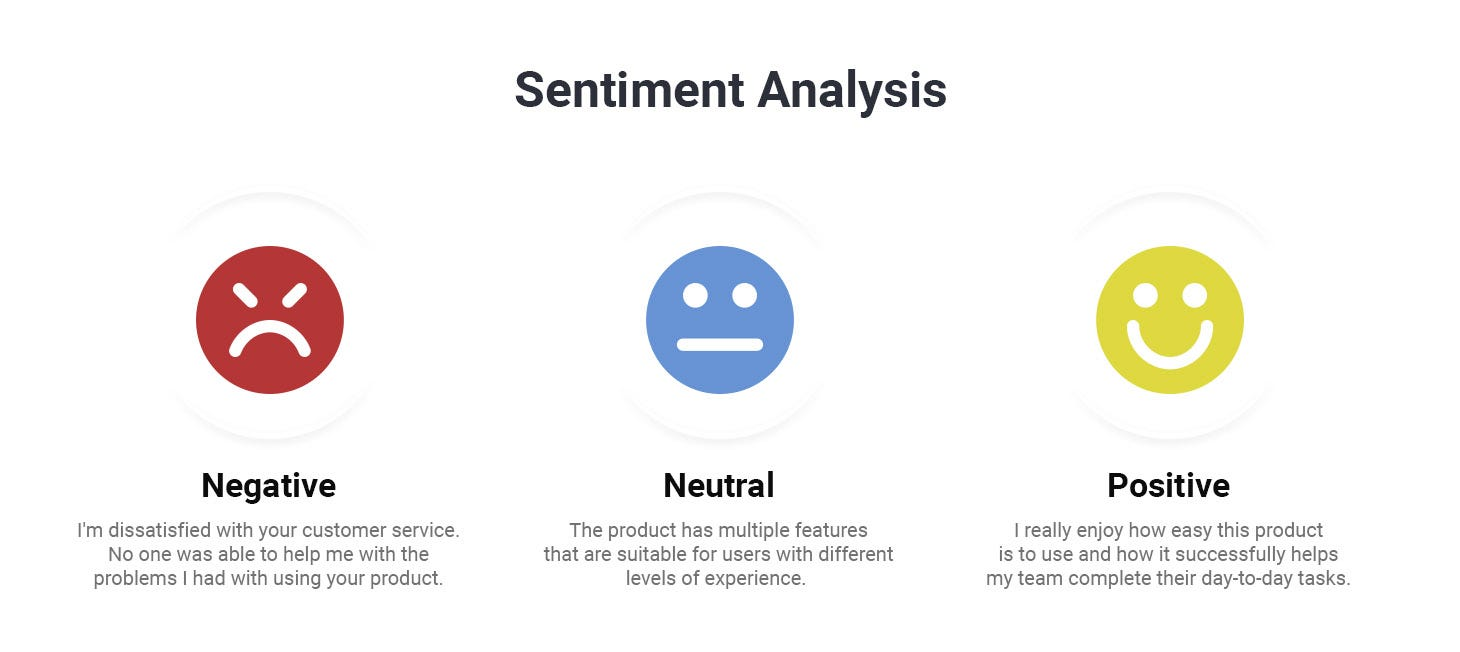

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [1]:
# Load the dataset
import pandas as pd
import glob
csv_matches = glob.glob('DisneylandReviews*.csv')
assert csv_matches, "No DisneylandReviews*.csv file found in this folder."
data = pd.read_csv(csv_matches[0], encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [2]:
#Check for missing values
data.isna().sum()

Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

In [3]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [4]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [5]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [6]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [7]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

### Getting the Dataset (Local / VS Code)

You're running this notebook locally (not in Google Colab), so `/content/...` paths won't work here.

Just place `Amazon_Unlocked_Mobile.csv` in the **same folder as this notebook**, and the code below will find it automatically using a relative path. If you'd rather keep it somewhere else, replace the path in the next cell with the full Windows path to the file, e.g. `r"C:\Users\<you>\Downloads\Amazon_Unlocked_Mobile.csv"` (the `r` prefix avoids backslash-escaping issues).

In [9]:
# Quick check: does the file exist next to this notebook (any (1)/(2)/(3) suffix is fine)?
import glob
csv_matches = glob.glob('Amazon_Unlocked_Mobile*.csv')
assert csv_matches, (
    "No Amazon_Unlocked_Mobile*.csv file found next to this notebook. "
    "Either move the file here, or edit the path in the next cell."
)
print(f"Found the dataset file: {csv_matches[0]}")


Found the dataset file: Amazon_Unlocked_Mobile (4).csv


## Task 1: Load the Data and Preprocess It

We load the **Amazon Reviews: Unlocked Mobile Phones** dataset and apply five distinct preprocessing steps:
1. Handle missing values (drop rows with no review text or rating)
2. Convert review text to lowercase
3. Remove punctuation, digits, and special characters
4. Remove English stopwords
5. Map the numeric `Rating` column into three sentiment classes: `positive`, `negative`, `neutral`

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
import nltk
import glob
from nltk.corpus import stopwords

nltk.download('stopwords')

# Load the dataset (Amazon Reviews: Unlocked Mobile Phones)
csv_matches = glob.glob('Amazon_Unlocked_Mobile*.csv')
assert csv_matches, "No Amazon_Unlocked_Mobile*.csv file found in this folder."
data = pd.read_csv(csv_matches[0])
data.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [11]:
# Preprocessing Step 1: Check for and handle missing values
print(data.isna().sum())

# Drop rows with missing review text or rating
data = data.dropna(subset=['Reviews', 'Rating'])
print(f"Remaining rows after dropping missing values: {data.shape[0]}")


Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64
Remaining rows after dropping missing values: 413770


In [12]:
# Preprocessing Step 2 (labeling): Map star ratings to sentiment classes
data['Sentiment'] = data['Rating'].apply(
    lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral')
)
data[['Reviews', 'Rating', 'Sentiment']].head()


,Reviews,Rating,Sentiment
0,I feel so LUCKY to have found this used (phone...,5,positive
1,"nice phone, nice up grade from my pantach revu...",4,positive
2,Very pleased,5,positive
3,It works good but it goes slow sometimes but i...,4,positive
4,Great phone to replace my lost phone. The only...,4,positive


In [13]:
# Preprocessing Steps 3-5: Clean and normalize the review text
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Step 3: Convert text to lowercase
    text = str(text).lower()

    # Step 4: Remove punctuation, digits and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 5: Tokenize and remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

# Apply preprocessing to the review text
data['Clean_Review'] = data['Reviews'].apply(preprocess_text)

# Display cleaned reviews
data[['Reviews', 'Clean_Review', 'Sentiment']].head()


,Reviews,Clean_Review,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone us used hard phone...,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,positive
2,Very pleased,pleased,positive
3,It works good but it goes slow sometimes but i...,works good goes slow sometimes good phone love,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,positive


## Task 2: Train/Test Split

We split the cleaned data into training (80%) and testing (20%) sets, stratifying on `Sentiment` so that the class balance is preserved in both splits.

In [14]:
# Import necessary libraries
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(
    data['Clean_Review'],
    data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=data['Sentiment']
)

print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")


train_data size: (331016,)
test_data size: (82754,)


## Task 3: Feature Extraction Using TF-IDF

In [15]:
# Import necessary libraries
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

print(f"Train vectors shape: {train_vectors.shape}")
print(f"Test vectors shape: {test_vectors.shape}")


Train vectors shape: (331016, 1000)
Test vectors shape: (82754, 1000)


## Task 4: Train a Naive Bayes Classifier

In [16]:
# Import necessary libraries
from sklearn.naive_bayes import MultinomialNB

# Train the Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = nb_classifier.predict(test_vectors)


## Task 5: Evaluate the Model on the Test Set

In [17]:
# Import necessary libraries
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.68      0.73     19412
     neutral       0.32      0.02      0.04      6352
    positive       0.84      0.97      0.90     56990

    accuracy                           0.83     82754
   macro avg       0.65      0.56      0.56     82754
weighted avg       0.79      0.83      0.79     82754



## Task 6: Print the Confusion Matrix

Confusion Matrix:
[[13187    73  6152]
 [ 1883   135  4334]
 [ 1660   209 55121]]


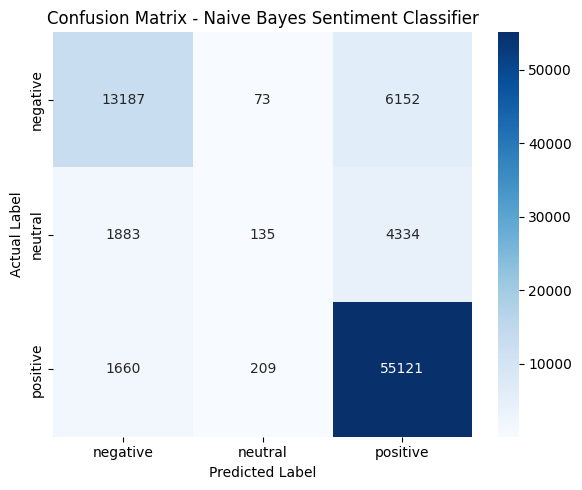

In [18]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
labels_order = nb_classifier.classes_
cm = confusion_matrix(test_labels, predictions, labels=labels_order)
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Naive Bayes Sentiment Classifier')
plt.tight_layout()
plt.show()


## What I Learned

- **Preprocessing pipeline**: cleaning raw review text (lowercasing, removing punctuation/digits, removing stopwords) and deriving a categorical `Sentiment` label from a numeric `Rating` column are both preprocessing steps — one on the input (X), one on the target (y) — and both matter for classification quality.
- **Stratified splitting**: passing `stratify=` to `train_test_split` keeps the positive/negative/neutral proportions consistent between the train and test sets, which matters here since the classes are heavily imbalanced: ~69% positive, ~23% negative, only ~8% neutral.
- **TF-IDF vs. raw counts**: TF-IDF down-weights very common words across the corpus and up-weights words that are distinctive to a given review, which generally helps a probabilistic classifier separate sentiment classes better than raw word counts would.
- **Naive Bayes for text**: `MultinomialNB` is a strong, fast baseline for text classification because it models word frequencies directly and works well with the sparse, high-dimensional vectors TF-IDF produces — even though its independence assumption between words is technically wrong.
- **Accuracy isn't the whole story**: the model reached 83% overall accuracy, but the classification report shows this is driven almost entirely by the majority `positive` class (97% recall). The minority `neutral` class had only 2% recall — the model essentially never predicts "neutral" — which the confusion matrix confirms: most neutral reviews get misclassified as either positive or negative. This is a direct consequence of class imbalance, and it's exactly the kind of failure a single accuracy number hides.